# Классификация марок автомобилей: логистическая регрессия

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

Версия TensorFlow: 2.21.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score

In [41]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

DATA_DIR = Path("/home/sm/Desktop/ml/CarBrandClassificationDataset")

## 1. Загрузка структуры датасета

Ожидается структура:

```text
CarBrandClassificationDataset/
├── train/
│   ├── class_1/
│   └── ...
├── val/
│   ├── class_1/
│   └── ...
└── test/
    ├── class_1/
    └── ...
```

В таблицы ниже собираются пути к изображениям и строковые метки классов.

In [5]:
train_base = DATA_DIR / "train"
val_base = DATA_DIR / "val"
test_base = DATA_DIR / "test"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_split_df(split_dir: Path) -> pd.DataFrame:
    if not split_dir.exists():
        raise FileNotFoundError(f"Папка не найдена: {split_dir}")

    rows = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for cls_dir in class_dirs:
        cls = cls_dir.name
        for f in cls_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append((str(f), cls))
    return pd.DataFrame(rows, columns=["path", "label"])

df_train = build_split_df(train_base)
df_val = build_split_df(val_base)
df_test = build_split_df(test_base)

print("Количество изображений:")
print("Train:", len(df_train), "| классов:", df_train["label"].nunique())
print("Val  :", len(df_val), "| классов:", df_val["label"].nunique())
print("Test :", len(df_test), "| классов:", df_test["label"].nunique())

display(pd.concat({
    "train": df_train["label"].value_counts().sort_index(),
    "val": df_val["label"].value_counts().sort_index(),
    "test": df_test["label"].value_counts().sort_index(),
}, axis=1).fillna(0).astype(int).head())

Количество изображений:
Train: 11517 | классов: 33
Val  : 2475 | классов: 33
Test : 2475 | классов: 33


,train,val,test
label,,,
Acura,349,75,75
Aston Martin,349,75,75
Audi,349,75,75
BMW,349,75,75
Bentley,349,75,75


In [6]:
# Единое отображение классов в индексы.
classes = sorted(df_train["label"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
num_classes = len(classes)

for name, df in [("val", df_val), ("test", df_test)]:
    missing = set(df["label"].unique()) - set(classes)
    if missing:
        raise ValueError(f"В {name} есть классы, которых нет в train: {sorted(missing)}")

df_train["label_idx"] = df_train["label"].map(class2idx)
df_val["label_idx"] = df_val["label"].map(class2idx)
df_test["label_idx"] = df_test["label"].map(class2idx)

print("Число классов:", num_classes)
print("Пример отображения:", list(class2idx.items())[:10])
df_train.head()

Число классов: 33
Пример отображения: [('Acura', 0), ('Aston Martin', 1), ('Audi', 2), ('BMW', 3), ('Bentley', 4), ('Buick', 5), ('Cadillac', 6), ('Chevrolet', 7), ('Chrysler', 8), ('Dodge', 9)]


,path,label,label_idx
0,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
1,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
2,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
3,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
4,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0


## 2. Распределение изображений по классам

равномерное распределение по всем классам

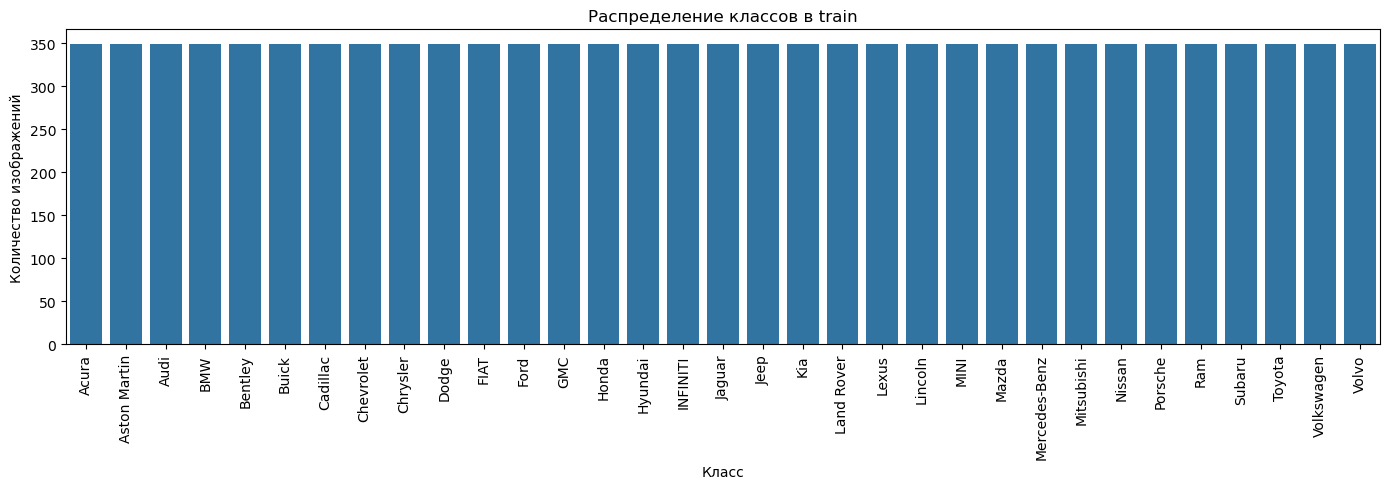

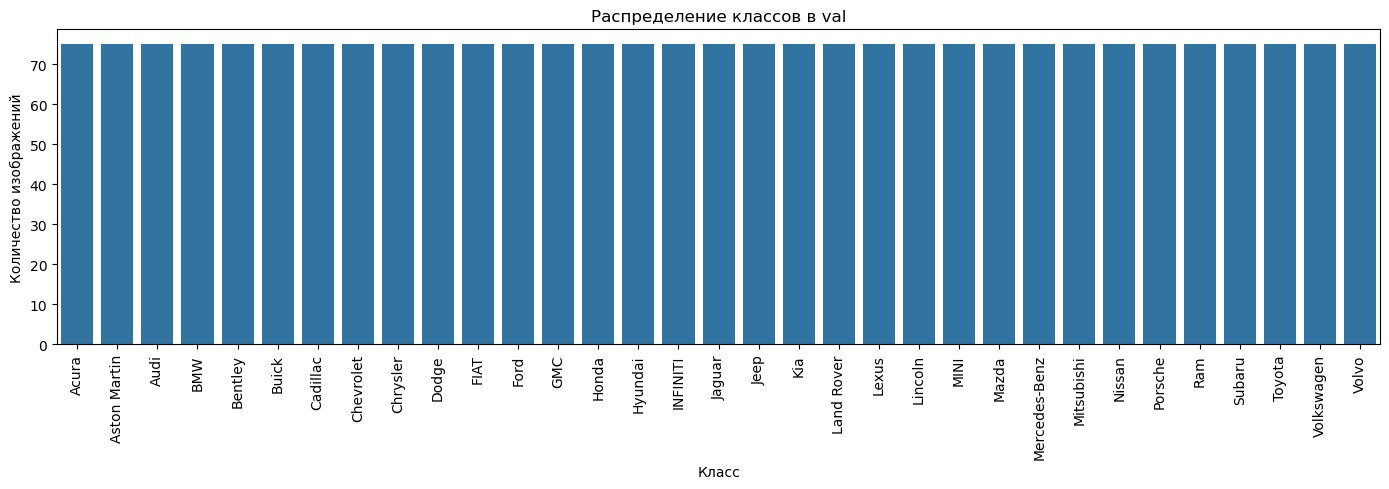

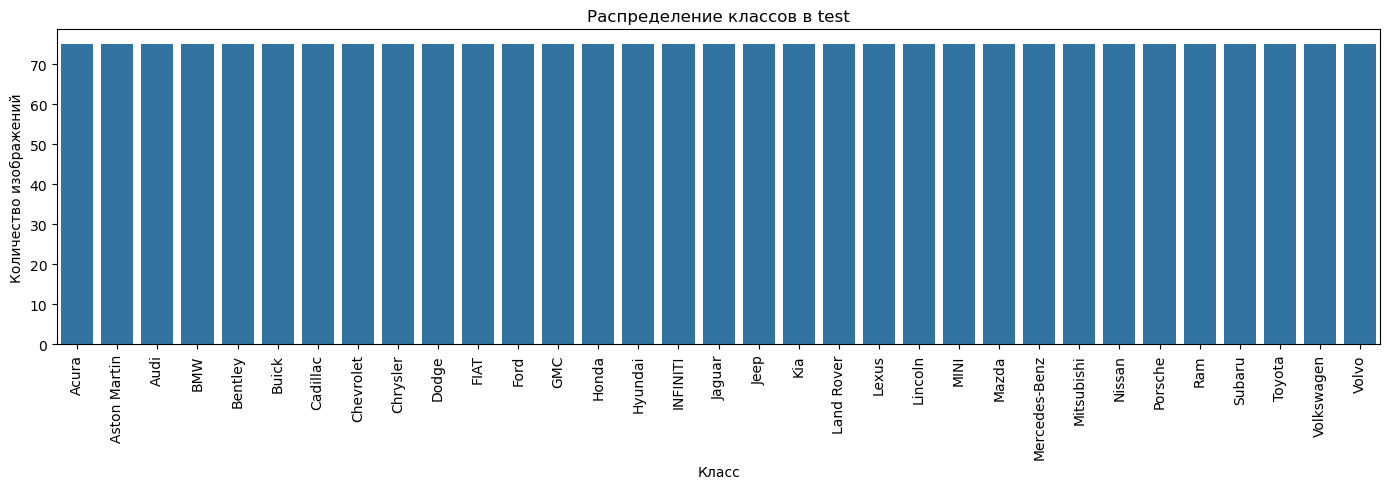

Коэффициент дисбаланса train max/min: 1.00


In [7]:
def plot_class_distribution(df: pd.DataFrame, title: str) -> None:
    counts = df["label"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(14, 5))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(title)
    plt.xlabel("Класс")
    plt.ylabel("Количество изображений")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_class_distribution(df_train, "Распределение классов в train")
plot_class_distribution(df_val, "Распределение классов в val")
plot_class_distribution(df_test, "Распределение классов в test")

class_counts = df_train["label_idx"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / max(class_counts.min(), 1)
print(f"Коэффициент дисбаланса train max/min: {imbalance_ratio:.2f}")

## 3. `tf.data`-пайплайн и аугментация

Используется resize_with_pad, т.к. для авто критичны пропорции (resize) и нельзя обрезать (crop) - мы рискуем потерять важную часть изображения

Для baseline-модели используются изображения в диапазоне `[0, 1]`.

Для EfficientNet используется `preprocess_input`, совместимый с ImageNet-предобучением. Аугментация стала сильнее, но без чрезмерных искажений: марку машины нельзя менять агрессивными трансформациями.

In [42]:
def decode_image(path):
    """Читает изображение, приводит к RGB, float32 и нужному размеру."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    return img

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmenter")


def make_feature_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        lambda x, y: (decode_image(x), y),
        num_parallel_calls=AUTO
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)

    return ds


train_ds_feat = make_feature_ds(
    df_train["path"].tolist(),
    df_train["label_idx"].tolist()
)

val_ds_feat = make_feature_ds(
    df_val["path"].tolist(),
    df_val["label_idx"].tolist()
)

test_ds_feat = make_feature_ds(
    df_test["path"].tolist(),
    df_test["label_idx"].tolist()
)

## 4. Примеры изображений

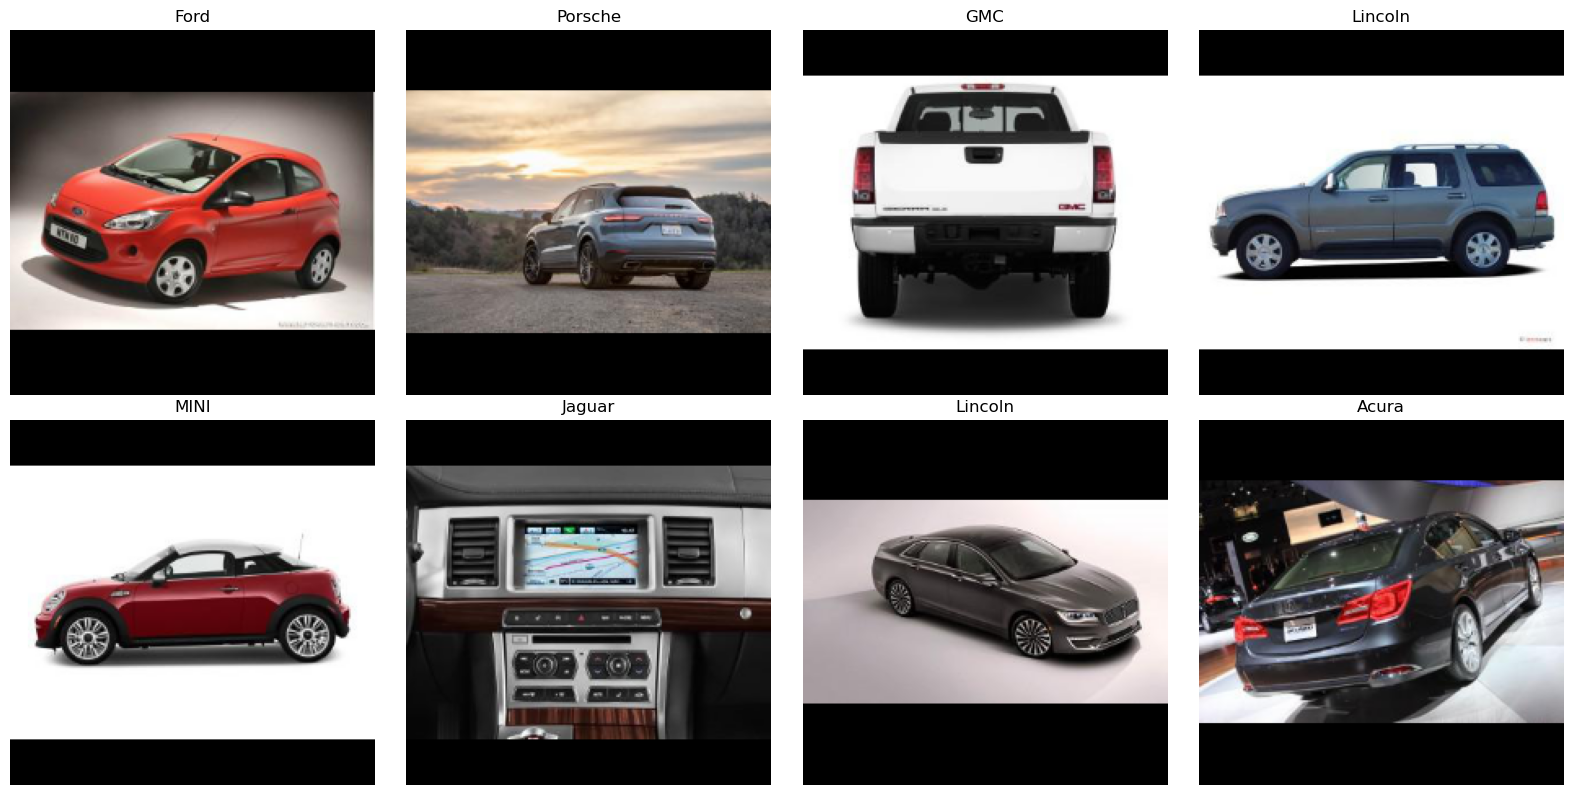

In [43]:
plt.figure(figsize=(16, 8))
i = 1
for x in list(df['path'].sample(8)):
    img = decode_image(x)
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(x.split('/')[-2])
    i += 1
plt.tight_layout()
plt.show()

## 5. Извлечение признаков

In [44]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

feature_extractor = models.Model(inputs, x)

feature_extractor.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [45]:
X_train = feature_extractor.predict(
    train_ds_feat,
    verbose=1
)

X_val = feature_extractor.predict(
    val_ds_feat,
    verbose=1
)

X_test = feature_extractor.predict(
    test_ds_feat,
    verbose=1
)

y_train = df_train["label_idx"].values
y_val = df_val["label_idx"].values
y_test = df_test["label_idx"].values

print(X_train.shape)

360/360 ━━━━━━━━━━━━━━━━━━━━ 39s 69ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
(11517, 1280)


## 6. Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

In [53]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        random_state=SEED,
    ))
])

logreg.fit(X_train, y_train)

val_pred = logreg.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)

print(f"Validation accuracy: {val_acc:.4f}")

Validation accuracy: 0.2190


In [56]:
param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 3.0],
    "clf__solver": ["lbfgs"],
}

search = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_grid,
    n_iter=6,
    scoring="accuracy",
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Best params:")
print(search.best_params_)

print("\nBest CV score:")
print(search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/sm/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END .....................clf__C=0.01, clf__solver=lbfgs; total time=  13.0s
[CV] END .....................clf__C=0.01, clf__solver=lbfgs; total time=  18.8s
[CV] END .....................clf__C=0.01, clf__solver=lbfgs; total time=  20.9s
[CV] END ......................clf__C=0.1, clf__solver=lbfgs; total time=  32.0s
[CV] END ......................clf__C=0.1, clf__solver=lbfgs; total time=  33.6s
[CV] END ......................clf__C=0.1, clf__solver=lbfgs; total time=  42.9s
[CV] END ......................clf__C=1.0, clf__solver=lbfgs; total time= 1.3min
[CV] END ......................clf__C=1.0, clf__solver=lbfgs; total time= 1.3min
[CV] END ......................clf__C=1.0, clf__solver=lbfgs; total time= 1.4min
[CV] END ......................clf__C=3.0, clf__solver=lbfgs; total time= 1.7min
[CV] END ......................clf__C=3.0, clf__solver=lbfgs; total time= 1.8min
[CV] END ......................clf__C=3.0, clf__solver=lbfgs; total time= 1.8min
Best params:
{'clf__solver':

In [59]:
best_logreg = search.best_estimator_

val_pred = best_logreg.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)

print(f"Validation accuracy: {val_acc:.4f}")

Validation accuracy: 0.2356


In [60]:
test_pred = best_logreg.predict(X_test)

test_acc = accuracy_score(y_test, test_pred)

print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.2339


In [66]:
report = classification_report(
        y_test,
        test_pred,
        target_names=classes,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
Acura,0.164557,0.173333,0.168831,75.000000
Aston Martin,0.323810,0.453333,0.377778,75.000000
Audi,0.267606,0.253333,0.260274,75.000000
BMW,0.117647,0.080000,0.095238,75.000000
Bentley,0.189189,0.186667,0.187919,75.000000
Buick,0.239437,0.226667,0.232877,75.000000
Cadillac,0.173913,0.160000,0.166667,75.000000
Chevrolet,0.216667,0.173333,0.192593,75.000000
Chrysler,0.305263,0.386667,0.341176,75.000000
Dodge,0.183333,0.146667,0.162963,75.000000


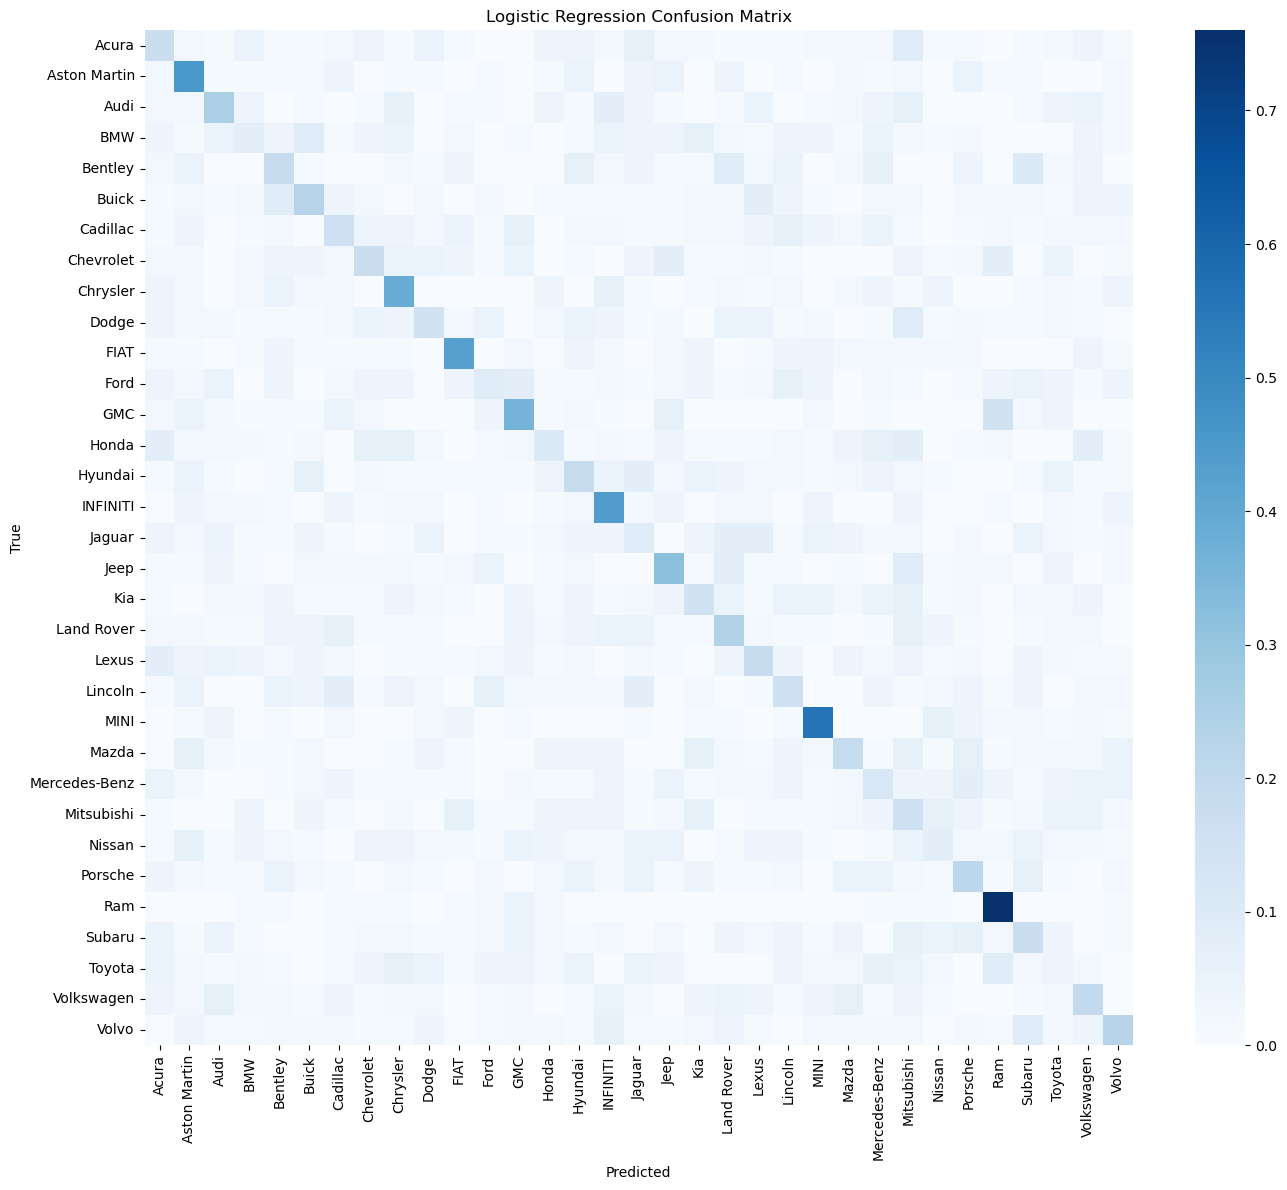

In [68]:
cm = confusion_matrix(y_test, test_pred)
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

In [69]:
joblib.dump(
    best_logreg,
    "models/logistic_regression_effnet_features.pkl"
)

['models/logistic_regression_effnet_features.pkl']

## 7. Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEED,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

val_pred_rf = rf.predict(X_val)

val_acc_rf = accuracy_score(y_val, val_pred_rf)

print(f"Validation accuracy: {val_acc_rf:.4f}")

Validation accuracy: 0.3188


In [74]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,
    ),
    param_distributions=param_grid_rf,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    verbose=2,
    random_state=SEED,
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

print("Best params:")
print(rf_search.best_params_)

print("\nBest CV score:")
print(rf_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  18.8s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  18.7s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  19.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  22.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  23.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  25.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  10.5s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimator

In [75]:
best_rf = rf_search.best_estimator_

val_pred_rf = best_rf.predict(X_val)

val_acc_rf = accuracy_score(y_val, val_pred_rf)

print(f"Validation accuracy: {val_acc_rf:.4f}")

Validation accuracy: 0.3414


In [76]:
test_pred_rf = best_rf.predict(X_test)

test_acc_rf = accuracy_score(y_test, test_pred_rf)

print(f"Test accuracy: {test_acc_rf:.4f}")

Test accuracy: 0.3511


In [77]:
report_rf = classification_report(
        y_test,
        test_pred_rf,
        target_names=classes,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

report_rf_df = pd.DataFrame(report_rf).T
display(report_rf_df)

,precision,recall,f1-score,support
Acura,0.262136,0.360000,0.303371,75.000000
Aston Martin,0.397959,0.520000,0.450867,75.000000
Audi,0.257576,0.226667,0.241135,75.000000
BMW,0.186441,0.146667,0.164179,75.000000
Bentley,0.198529,0.360000,0.255924,75.000000
Buick,0.513514,0.506667,0.510067,75.000000
Cadillac,0.404255,0.253333,0.311475,75.000000
Chevrolet,0.344828,0.266667,0.300752,75.000000
Chrysler,0.592593,0.640000,0.615385,75.000000
Dodge,0.339286,0.253333,0.290076,75.000000


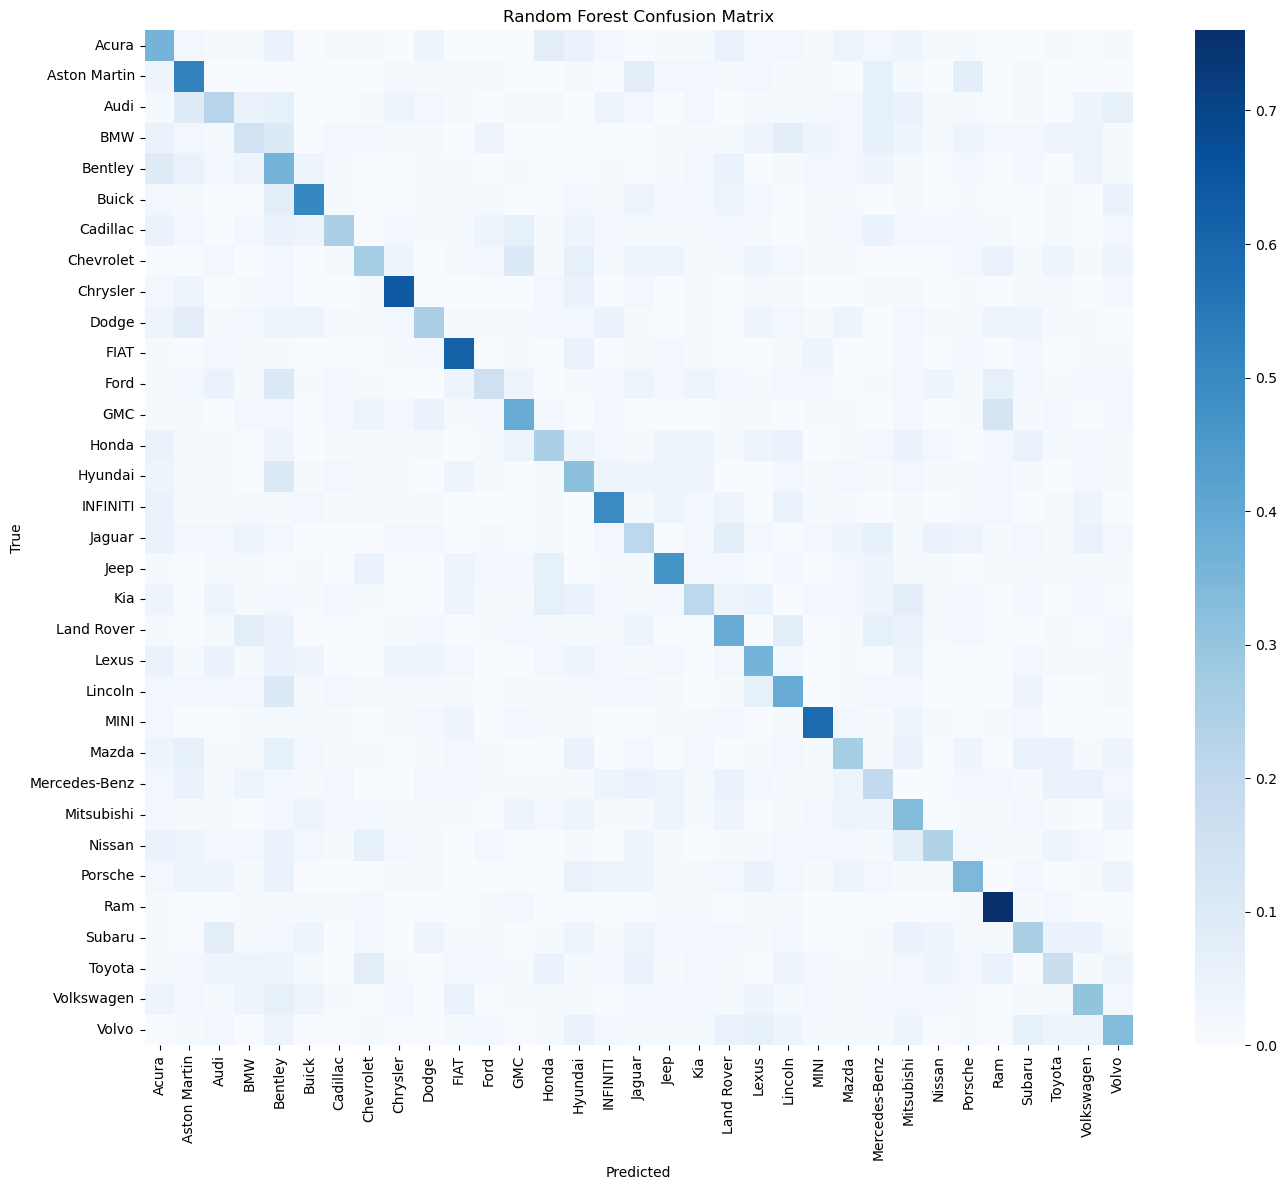

In [78]:
cm = confusion_matrix(y_test, test_pred_rf)
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

In [79]:
joblib.dump(
    best_rf,
    "models/random_forest_effnet_features.pkl"
)

['models/random_forest_effnet_features.pkl']

In [80]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
    ],
    "Validation Accuracy": [
        val_acc,
        val_acc_rf,
    ],
    "Test Accuracy": [
        test_acc,
        test_acc_rf,
    ]
})

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Validation Accuracy,Test Accuracy
1,Random Forest,0.341414,0.351111
0,Logistic Regression,0.235556,0.233939
